# Linear Regression — A Step-by-Step Guide

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davidrajm/DSA-DL-FDP/blob/main/Day%2002%20-%20Machine%20Learning%20-%20Dr%20Arun%20RajKumar/Lab%20Sessions/07_k-means.ipynb)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.utils import Bunch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
X_raw, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=7,
    n_redundant=2,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(X_raw.shape[1])]
dataset = Bunch(
    data=X_raw,
    target=y,
    feature_names=feature_names,
    DESCR="Synthetic 3-class classification dataset via make_classification"
)

In [3]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

X = df.drop(columns='target')   # Feature matrix
y = df['target']

In [4]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=42
)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",20
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [6]:
print("K-Means model fitted.")
print(f"  n_clusters   : {kmeans.n_clusters}")
print(f"  Inertia      : {kmeans.inertia_:.4f}")
print(f"  Iterations   : {kmeans.n_iter_}")
print(f"  Silhouette   : {silhouette_score(X, kmeans.labels_):.4f}")

K-Means model fitted.
  n_clusters   : 3
  Inertia      : 13300.0467
  Iterations   : 9
  Silhouette   : 0.2035


In [9]:
def plot_kmeans_results(
    kmeans,
    X,
    y,
    feature_names,
    class_meta=None,
    figsize=(17, 4),
):
    """
    Prints cluster summary and plots K-Means results.

    Parameters
    ----------
    kmeans        : Fitted KMeans object
    X_scaled      : Scaled feature matrix (all samples)
    y             : True target labels (for comparison)
    feature_names : List of feature names
    class_meta    : List of (label, name, color) tuples
                    Default: [(0,"Low","#C44E52"), (1,"Medium","#55A868"), (2,"High","#4C72B0")]
    figsize       : Figure size for the 3-panel plot  (default: (17, 4))
    """

    if class_meta is None:
        class_meta = [
            (0, "Low",    "#C44E52"),
            (1, "Medium", "#55A868"),
            (2, "High",   "#4C72B0"),
        ]

    labels      = kmeans.labels_
    centers     = kmeans.cluster_centers_
    n_clusters  = kmeans.n_clusters
    colors      = [m[2] for m in class_meta]

    # ── Cluster Summary Table ─────────────────────────────────────────────────
    print(f"\n  {'Cluster':<12} {'Size':>8} {'% Share':>10} {'Inertia':>12}")
    print(f"  {'-' * 44}")

    cluster_inertias = []
    for k in range(n_clusters):
        mask      = labels == k
        size      = mask.sum()
        share     = size / len(labels) * 100
        dists     = np.sum((X[mask] - centers[k]) ** 2, axis=1)
        inertia_k = dists.sum()
        bar       = "█" * int(share / 5)
        cluster_inertias.append(inertia_k)
        print(f"  Cluster {k:<4} {size:>8} {share:>9.1f}%  {inertia_k:>11.2f}  {bar}")

    print(f"\n  Total Inertia : {kmeans.inertia_:.4f}")
    print(f"  Silhouette    : {silhouette_score(X, labels):.4f}")

    # ── Figure Setup ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle("K-Means Clustering", fontsize=13, fontweight="bold")

    # ── Panel 1 : Per-Cluster Inertia ─────────────────────────────────────────
    axes[0].bar(
        [f"Cluster {k}" for k in range(n_clusters)],
        cluster_inertias,
        color=colors[:n_clusters], edgecolor="white"
    )
    axes[0].axhline(
        np.mean(cluster_inertias),
        color="red", linestyle="--", lw=1.5, label="Mean Inertia"
    )
    axes[0].set_title("Per-Cluster Inertia")
    axes[0].set_xlabel("Cluster")
    axes[0].set_ylabel("Inertia (Sum of Squared Distances)")
    axes[0].legend(fontsize=8)

    # ── Panel 2 : 2D Scatter via PCA ──────────────────────────────────────────
    pca2       = PCA(n_components=2, random_state=42)
    X_pca2     = pca2.fit_transform(X)
    centers_2d = pca2.transform(centers)
    exp2       = pca2.explained_variance_ratio_

    for k, color in enumerate(colors[:n_clusters]):
        mask = labels == k
        axes[1].scatter(
            X_pca2[mask, 0], X_pca2[mask, 1],
            label=f"Cluster {k}", color=color,
            alpha=0.6, edgecolors="white", s=50
        )
    axes[1].scatter(
        centers_2d[:, 0], centers_2d[:, 1],
        marker="X", s=200, color="black",
        edgecolors="white", linewidths=0.8,
        zorder=5, label="Centroids"
    )
    axes[1].set_xlabel(f"PC1 ({exp2[0]*100:.1f}% var)")
    axes[1].set_ylabel(f"PC2 ({exp2[1]*100:.1f}% var)")
    axes[1].set_title("2D K-Means Clusters (PCA Projection)")
    axes[1].legend(fontsize=8)

    # ── Panel 3 : Centroids Heatmap ───────────────────────────────────────────
    centroid_df = pd.DataFrame(
        centers,
        index=[f"Cluster {k}" for k in range(n_clusters)],
        columns=feature_names
    )
    sns.heatmap(
        centroid_df, annot=True, fmt=".2f",
        cmap="coolwarm", linewidths=0.5,
        ax=axes[2]
    )
    axes[2].set_title("Cluster Centroids Heatmap")
    axes[2].set_xlabel("Feature")
    axes[2].set_ylabel("Cluster")

    plt.tight_layout()
    plt.show()



  Cluster          Size    % Share      Inertia
  --------------------------------------------
  Cluster 0         193      38.6%      4848.55  ███████
  Cluster 1         151      30.2%      4132.50  ██████
  Cluster 2         156      31.2%      4319.00  ██████

  Total Inertia : 13300.0467
  Silhouette    : 0.2035


/Users/davidrm/Documents/myrepos/DSA-DL-FDP/Day 02 - Machine Learning - Dr Arun RajKumar/Lab Sessions/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


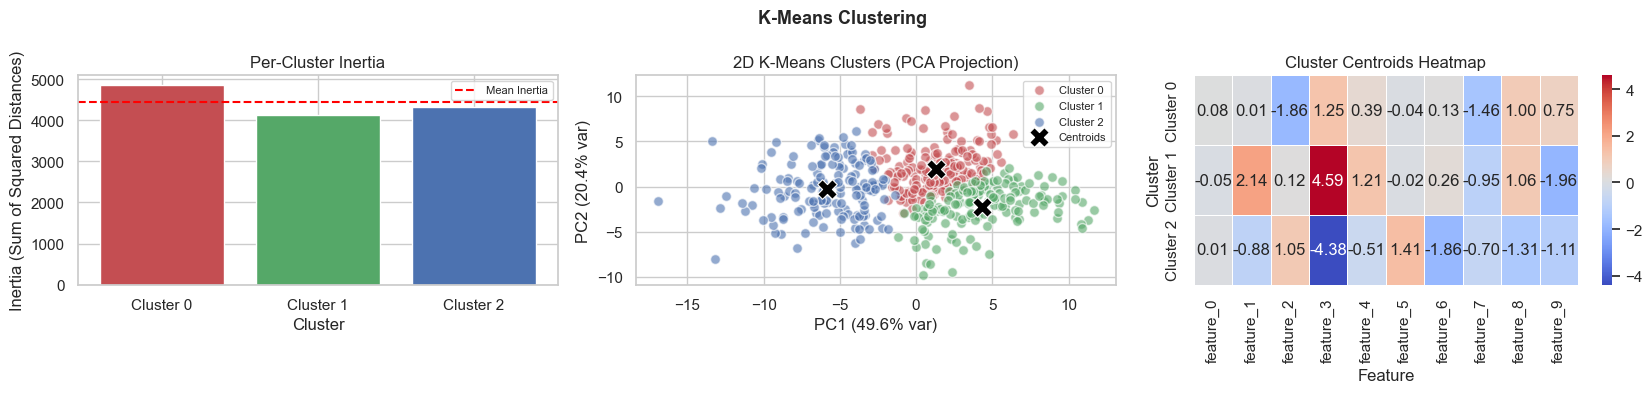

In [10]:
plot_kmeans_results(
    kmeans=kmeans,
    X=X,
    y=y,
    feature_names=feature_names,
)